<a href="https://colab.research.google.com/github/s24118-ui/SUML/blob/main/SUML_Projekt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Import Bibliotek

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/ASI')

df = pd.read_csv('Car_sale_ads.csv', sep=',')
print(df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
         Index  Price Currency Condition Vehicle_brand Vehicle_model  \
0            0  86200      PLN       New        Abarth           595   
1            1  43500      PLN      Used        Abarth         Other   
2            2  44900      PLN      Used        Abarth           500   
3            3  39900      PLN      Used        Abarth           500   
4            4  97900      PLN       New        Abarth           595   
...        ...    ...      ...       ...           ...           ...   
208299  208299  39900      PLN      Used           Żuk         Other   
208300  208300  10900      PLN      Used           Żuk         Other   
208301  208301   6900      PLN      Used           Żuk         Other   
208302  208302   5700      PLN      Used           Żuk         Other   
208303  208303  11900      PLN      Used           Żuk         Other   

      

#2. Spojrzenie ogólne na braki danych

In [ ]:
df.isnull().any()

,0
Index,False
Price,False
Currency,False
Condition,False
Vehicle_brand,False
Vehicle_model,False
Vehicle_version,True
Vehicle_generation,True
Production_year,False
Mileage_km,True


In [ ]:
data = df.copy()
missing_summary = pd.DataFrame({
    "missing_count": data.isna().sum(),
    "missing_%": data.isna().mean() * 100,
    "dtype": data.dtypes.astype(str)
}).sort_values("missing_%", ascending=False)

missing_only = missing_summary[missing_summary["missing_count"] > 0]
display(missing_only)

,missing_count,missing_%,dtype
First_owner,143210,68.750480,object
First_registration_date,121859,58.500557,object
CO2_emissions,114257,54.851083,float64
Origin_country,89992,43.202243,object
Vehicle_version,70222,33.711307,object
Vehicle_generation,60444,29.017206,object
Drive,15076,7.237499,object
Displacement_cm3,1966,0.943813,float64
Doors_number,1487,0.713861,float64
Mileage_km,983,0.471906,float64


In [ ]:
num_cols = data.select_dtypes(include=np.number).columns.tolist()
cat_cols = data.select_dtypes(include=["object", "category"]).columns.tolist()
date_cols = data.select_dtypes(include=["datetime64[ns]"]).columns.tolist()

print("Liczba kolumn numerycznych:", len(num_cols))
print("Liczba kolumn kategorycznych:", len(cat_cols))
print("Liczba kolumn datowych:", len(date_cols))

print("\nNumeryczne:")
print(num_cols)

print("\nKategoryczne:")
print(cat_cols)

print("\nDatowe:")
print(date_cols)

Liczba kolumn numerycznych: 8
Liczba kolumn kategorycznych: 17
Liczba kolumn datowych: 0

Numeryczne:
['Index', 'Price', 'Production_year', 'Mileage_km', 'Power_HP', 'Displacement_cm3', 'CO2_emissions', 'Doors_number']

Kategoryczne:
['Currency', 'Condition', 'Vehicle_brand', 'Vehicle_model', 'Vehicle_version', 'Vehicle_generation', 'Fuel_type', 'Drive', 'Transmission', 'Type', 'Colour', 'Origin_country', 'First_owner', 'First_registration_date', 'Offer_publication_date', 'Offer_location', 'Features']

Datowe:
[]


#3. EDA

#3.1 Braki danych

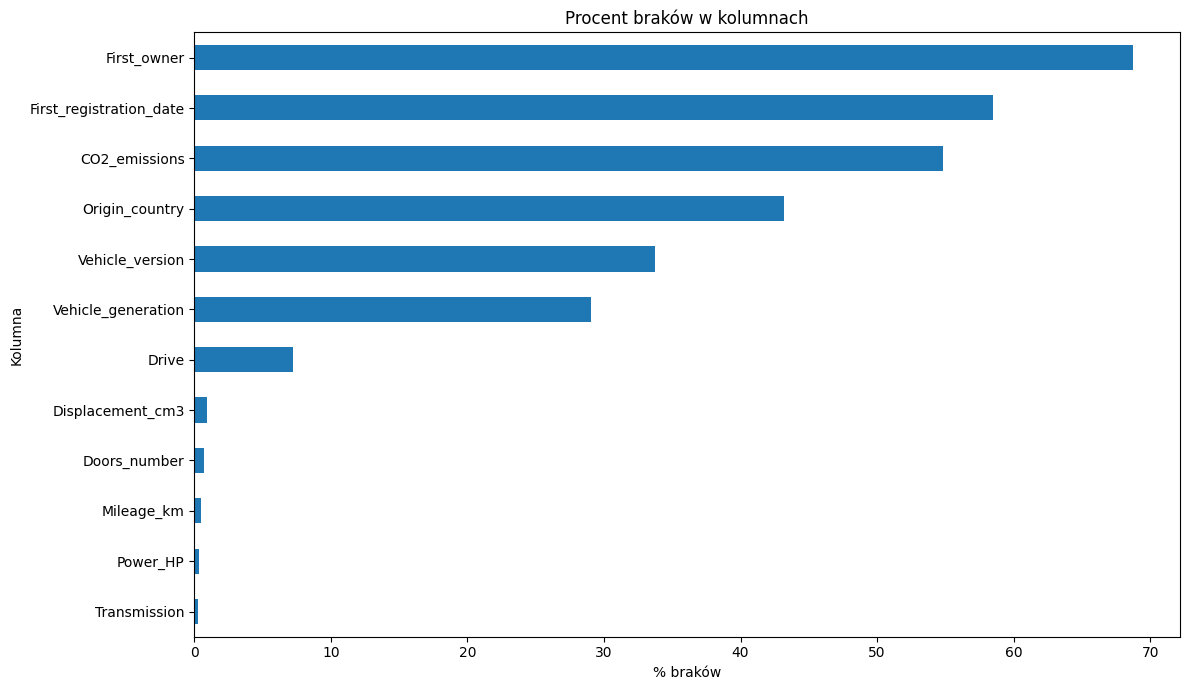

In [ ]:
missing_only = missing_summary[missing_summary["missing_count"] > 0]
plt.figure(figsize=(12, 7))
missing_only["missing_%"].sort_values().plot(kind="barh")
plt.title("Procent braków w kolumnach")
plt.xlabel("% braków")
plt.ylabel("Kolumna")
plt.tight_layout()
plt.show()


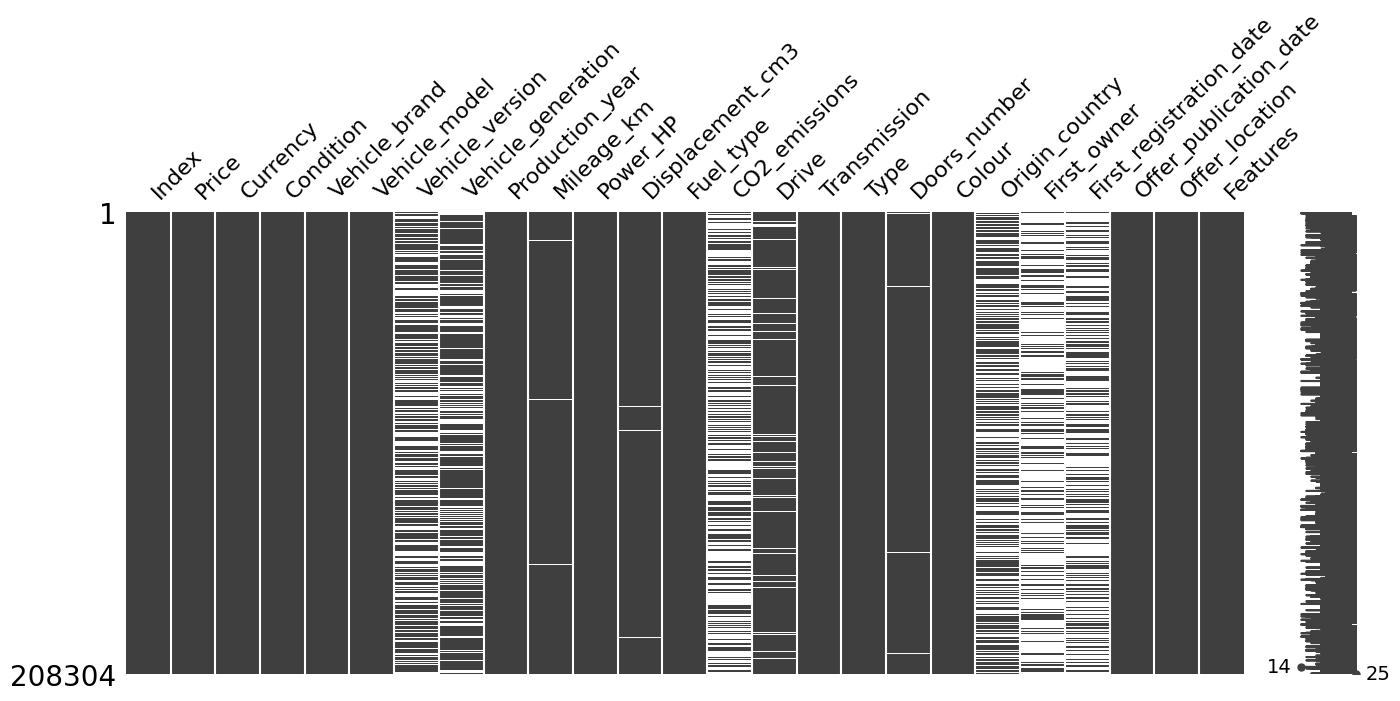

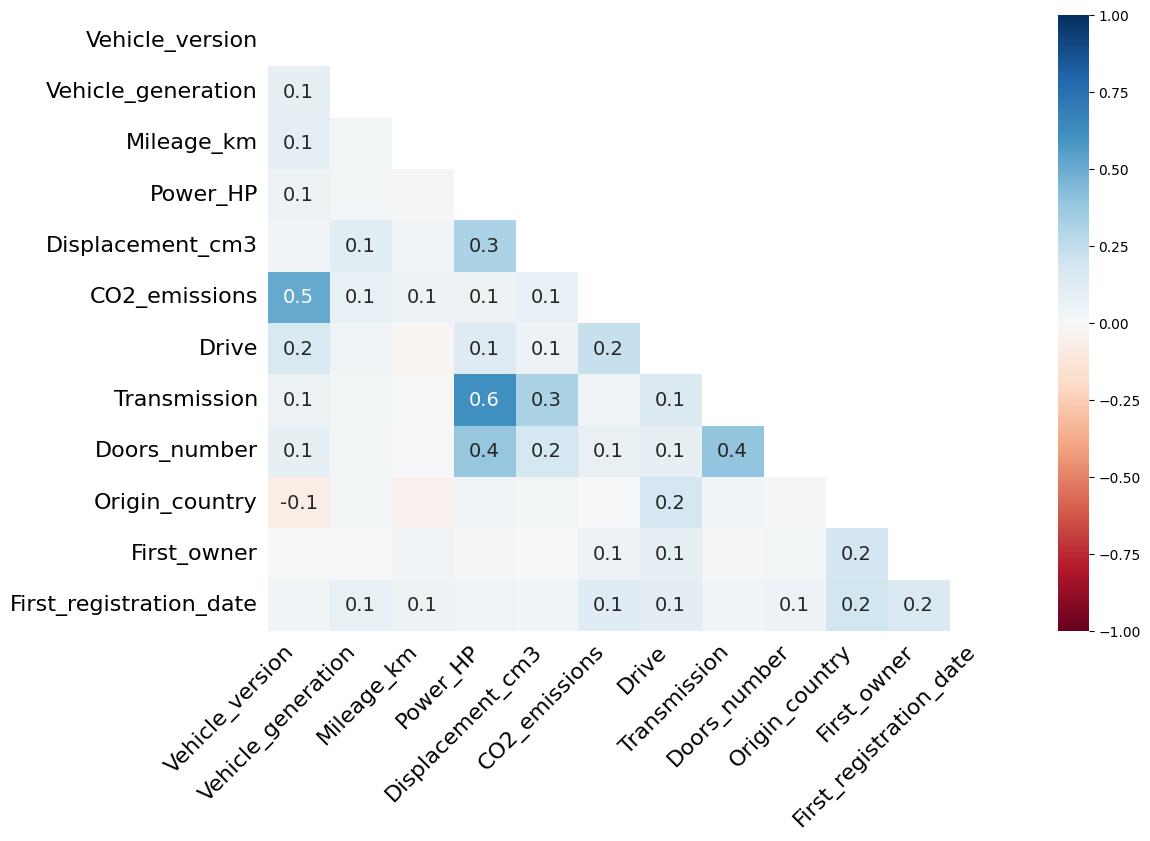

In [ ]:
msno.matrix(data, figsize=(16, 6))
plt.show()

msno.heatmap(data, figsize=(12, 8))
plt.show()

In [ ]:
data['First_owner'].head(20)

,First_owner
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
5,Yes
6,NaN
7,Yes
8,NaN
9,NaN


#3.1.1 Kolumna "First Owner". Brak jest jednoznaczny z "No", więc trzeba to narzucić.

In [ ]:
data['First_owner'] = data['First_owner'].map({'Yes': 1}).fillna(0).astype(int)

In [ ]:
data['First_registration_date'].head(20)

,First_registration_date
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
5,15/03/2016
6,25/02/2021
7,NaN
8,NaN
9,NaN


#3.1.2 Kolumna daty pierwszej rejestracji pojazdu  nie posiada wartych uwagi korelacji a imputacja nie przyniesie żadnej pozytywnej wartości + ogromne braki = decyzja o porzuceniu tej cechy.

In [ ]:
data = data.drop('First_registration_date', axis=1)

KeyError: "['First_registration_date'] not found in axis"

In [ ]:
data['CO2_emissions'].sample(20, random_state=42)

,CO2_emissions
104392,152.0
64876,184.0
27906,NaN
156533,132.0
13130,156.0
58276,NaN
56873,NaN
122154,129.0
175163,NaN
99161,206.0


#3.1.3 Kolumna emisji CO2 posiada zależności od typu silnika, pojemności silnika oraz wersji samochodu, stąd postanowienie o wykonaniu uzupełnienia braków medianą dla podobnych samochodów, stosując uzupełnienie od największych zależności, to co raz mniejsze tak aby ostatecznie uzupełnić jak najbardziej zbliżonymi realnie wartościami

In [ ]:
data['CO2_emissions'] = data['CO2_emissions'].fillna(
    data.groupby(['Fuel_type', 'Displacement_cm3', 'Vehicle_version'])['CO2_emissions'].transform('median')
)

data['CO2_emissions'] = data['CO2_emissions'].fillna(
    data.groupby(['Fuel_type', 'Displacement_cm3'])['CO2_emissions'].transform('median')
)

data['CO2_emissions'] = data['CO2_emissions'].fillna(
    data.groupby(['Fuel_type'])['CO2_emissions'].transform('median')
)

data['CO2_emissions'] = data['CO2_emissions'].fillna(
    data['CO2_emissions'].median()
)

In [ ]:
data['Vehicle_version'].sample(20, random_state=42)

,Vehicle_version
104392,200 d 4-Matic
64876,2.0
27906,NaN
156533,1.5 TSI FR
13130,3.0 TDI Quattro S tronic
58276,NaN
56873,NaN
122154,1.4 16V
175163,NaN
99161,AMG 63 S 4-Matic+


#3.1.4 Wersje samochodu to zlepek różnych informacji, nie nadający się do uzupełniania ani wzięcia pod uwagę przy trenowaniu. Decyzja o usunięciu.

In [ ]:
data = data.drop(columns=['Vehicle_version'])

In [ ]:
data['Vehicle_generation'].sample(20, random_state=42)

,Vehicle_generation
104392,NaN
64876,Mk4 (2007-2014)
27906,E60/E61 (2003-2010)
156533,IV (2020 - )
13130,C7 (2011-2018)
58276,Mk2 (2004-2011)
56873,NaN
122154,D (2006-2014)
175163,NaN
99161,W213 (2016-)


#3.1.5 Generacja pojazdu jest istotną informacją, więc nie możemy jej porzucić, ale również nie możemy uzupełnić w sensowny sposób (można pokusić się o uzupełnianie na podstawie rocznika oraz modelu ale jest ryzyko wprowadzania błędnych danych, więc pozostawiono decyzję o wprowadzeniu "Unknown", ponieważ brak informacji też jest informacją.

In [ ]:
data['Vehicle_generation'] = data['Origin_country'].fillna('Unknown')

In [ ]:
data['Drive'].sample(20, random_state=42)

,Drive
104392,4x4 (permanent)
64876,Front wheels
27906,Rear wheels
156533,Front wheels
13130,4x4 (permanent)
58276,NaN
56873,Front wheels
122154,Front wheels
175163,Front wheels
99161,4x4 (permanent)


In [ ]:
pd.crosstab(
    data['Vehicle_model'],
    data['Drive']
)

Drive,4x4 (attached automatically),4x4 (attached manually),4x4 (permanent),Front wheels,Rear wheels
Vehicle_model,,,,,
1.3,0,0,0,2,0
1.5,0,0,0,0,5
1.6,0,0,0,0,4
100,0,0,2,18,0
100 NX,0,0,0,1,0
...,...,...,...,...,...
ix20,0,0,0,184,1
ix35,113,38,14,490,0
ix55,0,0,4,0,0


In [ ]:
data['Displacement_cm3'].head(20)

,Displacement_cm3
0,1400.0
1,1100.0
2,1368.0
3,1368.0
4,1368.0
5,1368.0
6,1368.0
7,1368.0
8,1368.0
9,1398.0


In [ ]:
data['Power_HP'].head(20)

,Power_HP
0,145.0
1,75.0
2,180.0
3,160.0
4,165.0
5,180.0
6,145.0
7,145.0
8,180.0
9,145.0
